In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('FastagFraudDetection.csv')

In [9]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Transaction_ID         5000 non-null   int64
 1   Timestamp              5000 non-null   str  
 2   Vehicle_Type           5000 non-null   str  
 3   FastagID               4451 non-null   str  
 4   TollBoothID            5000 non-null   str  
 5   Lane_Type              5000 non-null   str  
 6   Vehicle_Dimensions     5000 non-null   str  
 7   Transaction_Amount     5000 non-null   int64
 8   Amount_paid            5000 non-null   int64
 9   Geographical_Location  5000 non-null   str  
 10  Vehicle_Speed          5000 non-null   int64
 11  Vehicle_Plate_Number   5000 non-null   str  
 12  Fraud_indicator        5000 non-null   str  
dtypes: int64(4), str(9)
memory usage: 507.9 KB


In [11]:
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

/tmp/ipykernel_132581/705781385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fraud_indicator', palette='Set2')


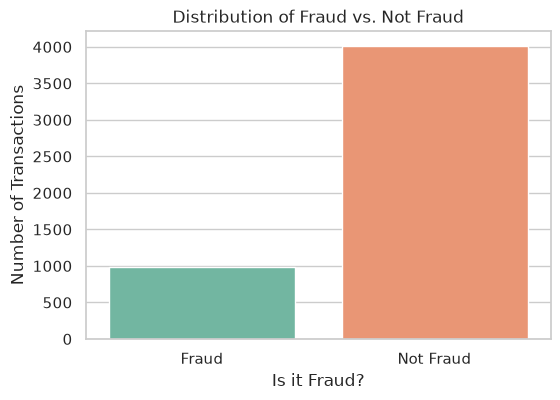

Not Fraud: 80.34%
Fraud: 19.66%


In [12]:
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a bar chart for the Fraud_indicator
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Fraud_indicator', palette='Set2')
plt.title('Distribution of Fraud vs. Not Fraud')
plt.xlabel('Is it Fraud?')
plt.ylabel('Number of Transactions')
plt.show()

# Calculate the exact percentages
fraud_counts = df['Fraud_indicator'].value_counts(normalize=True) * 100
print(f"Not Fraud: {fraud_counts['Not Fraud']:.2f}%")
print(f"Fraud: {fraud_counts['Fraud']:.2f}%")

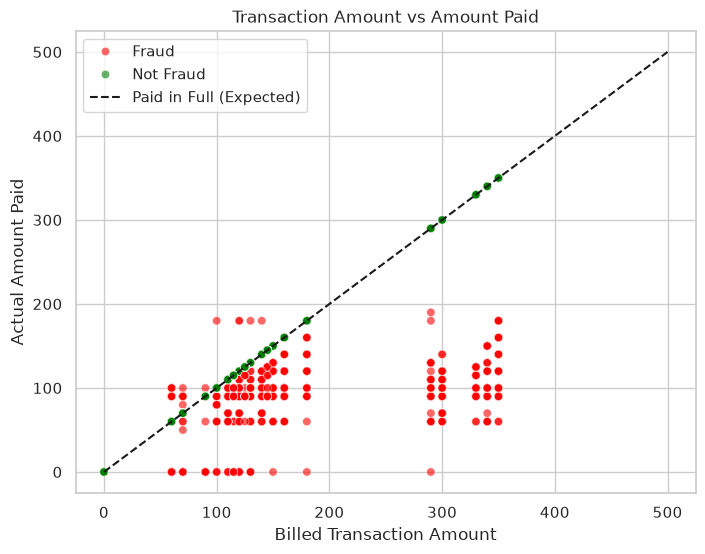

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x='Transaction_Amount', 
    y='Amount_paid', 
    hue='Fraud_indicator', 
    palette={'Fraud': 'red', 'Not Fraud': 'green'},
    alpha=0.6
)

# Draw a diagonal line where Transaction_Amount == Amount_paid
plt.plot([0, 500], [0, 500], 'k--', label='Paid in Full (Expected)')

plt.title('Transaction Amount vs Amount Paid')
plt.xlabel('Billed Transaction Amount')
plt.ylabel('Actual Amount Paid')
plt.legend()
plt.show()

<Axes: >

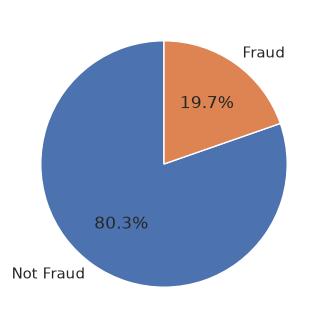

In [14]:
df['Fraud_indicator'].value_counts().plot(kind='pie', color=['green', 'red'], figsize=(6, 4), autopct='%1.1f%%', startangle=90)

<Axes: xlabel='Vehicle_Type', ylabel='count'>

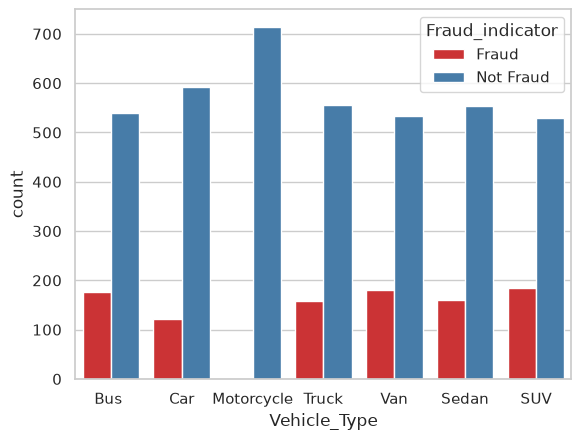

In [15]:
sns.countplot(data=df, x='Vehicle_Type', hue='Fraud_indicator', palette='Set1')

<Axes: xlabel='Vehicle_Dimensions', ylabel='count'>

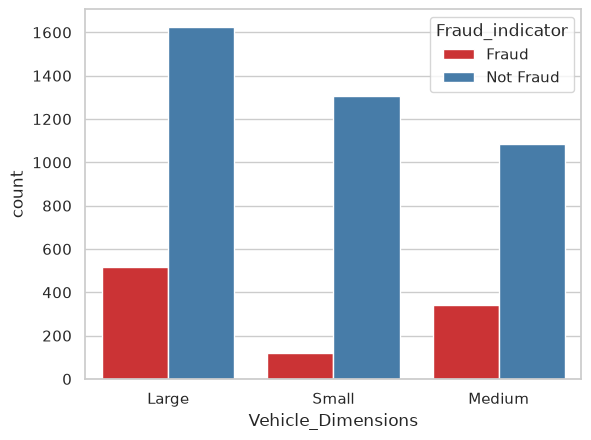

In [16]:
sns.countplot(data=df, x = 'Vehicle_Dimensions', hue='Fraud_indicator', palette='Set1')

Feature extraction


In [17]:
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

In [18]:
df['state_code'] = df['Vehicle_Plate_Number'].str[:2]

In [19]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator,state_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud,KA


In [20]:
df.drop(['Vehicle_Plate_Number'], axis=1, inplace=True)

In [21]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,state_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,KA


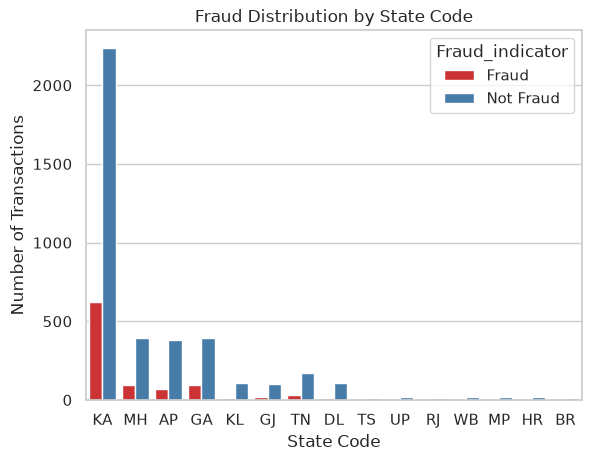

In [22]:
# visualize fraud based on state codes

sns.set_theme(style="whitegrid")
plt.Figure(figsize=(12, 6))
plt.title('Fraud Distribution by State Code')
sns.countplot(data=df, x='state_code', hue='Fraud_indicator', palette='Set1')
plt.xlabel('State Code')
plt.ylabel('Number of Transactions')    
plt.show()

<Axes: xlabel='state_code'>

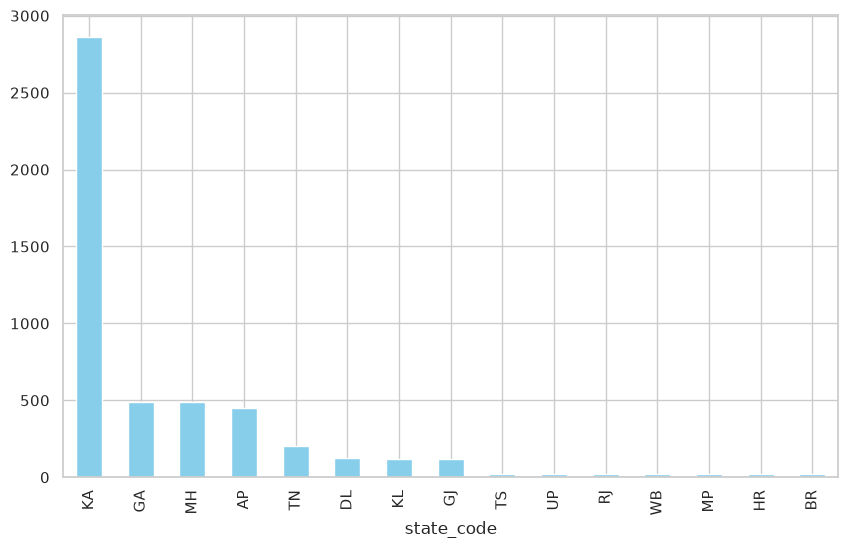

In [23]:
df['state_code'].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')

In [24]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [25]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

df.drop(['Timestamp'], axis=1, inplace=True)

In [26]:
df.head()

,Transaction_ID,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,state_code,Hour,Day_of_Week,Month
0,1,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,KA,11,4,1
1,2,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,KA,14,5,1
2,3,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,KA,18,6,1
3,4,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,KA,2,0,1
4,5,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,KA,6,1,1


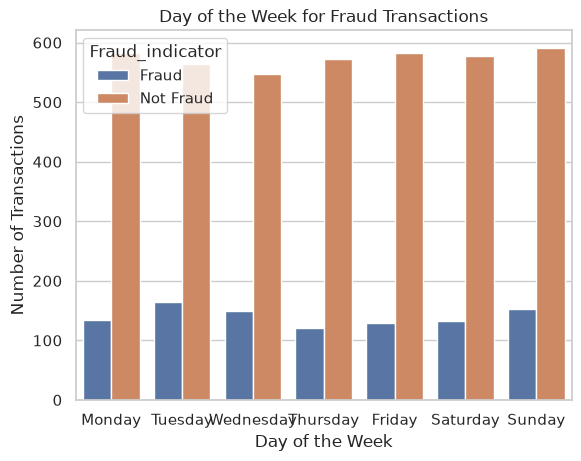

In [27]:
plt.Figure(figsize=(12, 6))
sns.countplot(data=df, x='Day_of_Week', hue='Fraud_indicator')
plt.title('Day of the Week for Fraud Transactions')
plt.xticks([0,1,2,3,4,5,6],['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.show()

In [28]:
numerical_features = df.select_dtypes('number')

In [29]:
numerical_features.head()

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed,Hour,Day_of_Week,Month
0,1,350,120,65,11,4,1
1,2,120,100,78,14,5,1
2,3,0,0,53,18,6,1
3,4,350,120,92,2,0,1
4,5,140,100,60,6,1,1


In [30]:
corrmat = numerical_features.corr()
corrmat

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed,Hour,Day_of_Week,Month
Transaction_ID,1.000000,-0.023515,0.044433,0.014378,-0.023208,0.002446,0.260075
Transaction_Amount,-0.023515,1.000000,0.870078,0.053229,-0.036980,-0.001813,-0.019824
Amount_paid,0.044433,0.870078,1.000000,0.039027,-0.026358,-0.002960,0.018105
Vehicle_Speed,0.014378,0.053229,0.039027,1.000000,-0.002259,-0.017608,0.015349
Hour,-0.023208,-0.036980,-0.026358,-0.002259,1.000000,-0.010292,0.001041
Day_of_Week,0.002446,-0.001813,-0.002960,-0.017608,-0.010292,1.000000,0.002552
Month,0.260075,-0.019824,0.018105,0.015349,0.001041,0.002552,1.000000


<Axes: >

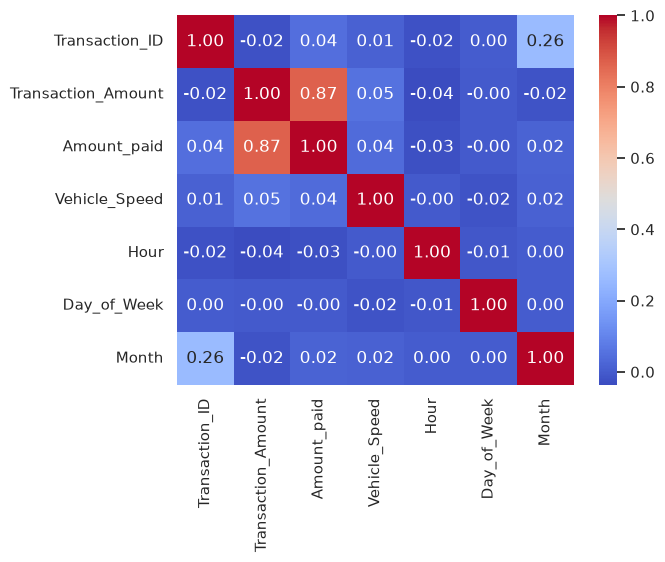

In [31]:
plt.Figure(figsize=(12, 6))
sns.heatmap(corrmat, annot=True, cmap='coolwarm', fmt=".2f")

In [32]:
df.drop(['Transaction_ID','FastagID', 'Geographical_Location'], axis =1, inplace =True)

In [33]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,state_code,Hour,Day_of_Week,Month
0,Bus,A-101,Express,Large,350,120,65,Fraud,KA,11,4,1
1,Car,B-102,Regular,Small,120,100,78,Fraud,KA,14,5,1
2,Motorcycle,D-104,Regular,Small,0,0,53,Not Fraud,KA,18,6,1
3,Truck,C-103,Regular,Large,350,120,92,Fraud,KA,2,0,1
4,Van,B-102,Express,Medium,140,100,60,Fraud,KA,6,1,1


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Vehicle_Type        5000 non-null   str  
 1   TollBoothID         5000 non-null   str  
 2   Lane_Type           5000 non-null   str  
 3   Vehicle_Dimensions  5000 non-null   str  
 4   Transaction_Amount  5000 non-null   int64
 5   Amount_paid         5000 non-null   int64
 6   Vehicle_Speed       5000 non-null   int64
 7   Fraud_indicator     5000 non-null   str  
 8   state_code          5000 non-null   str  
 9   Hour                5000 non-null   int32
 10  Day_of_Week         5000 non-null   int32
 11  Month               5000 non-null   int32
dtypes: int32(3), int64(3), str(6)
memory usage: 410.3 KB


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [36]:
lb = LabelEncoder()

In [37]:
objectColumns = ['Vehicle_Type', 'Lane_Type', 'Vehicle_Dimensions','TollBoothID','state_code', 'Fraud_indicator' ] #list of object columns
label_encoder = {}

for col in objectColumns:
    lb = LabelEncoder()
    df[col] = lb.fit_transform(df[col])
    label_encoder[col] = lb  # Store the label encoder for each column


In [38]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,state_code,Hour,Day_of_Week,Month
0,0,0,0,0,350,120,65,0,6,11,4,1
1,1,1,1,2,120,100,78,0,6,14,5,1
2,2,3,1,2,0,0,53,1,6,18,6,1
3,5,2,1,0,350,120,92,0,6,2,0,1
4,6,1,0,1,140,100,60,0,6,6,1,1


In [39]:
label_encoder['Fraud_indicator'].classes_


array(['Fraud', 'Not Fraud'], dtype=object)

In [40]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,state_code,Hour,Day_of_Week,Month
0,0,0,0,0,350,120,65,0,6,11,4,1
1,1,1,1,2,120,100,78,0,6,14,5,1
2,2,3,1,2,0,0,53,1,6,18,6,1
3,5,2,1,0,350,120,92,0,6,2,0,1
4,6,1,0,1,140,100,60,0,6,6,1,1


Model Training

In [41]:
x = df.drop('Fraud_indicator', axis=1)
y = df['Fraud_indicator']

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   

In [43]:
x_train.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,state_code,Hour,Day_of_Week,Month
4227,4,0,1,1,110,110,44,6,1,1,3
4676,3,1,0,0,145,145,61,5,20,2,2
800,2,5,1,2,0,0,45,6,8,6,8
3671,2,5,1,2,0,0,96,6,10,3,9
4193,3,1,1,0,140,140,74,2,5,6,9


In [44]:
# logistic regression model
from sklearn.linear_model import LogisticRegression 
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)
y_pred

/home/ravi-kumar-pal/ML Internship/Machine Learning Internship MIP-ML-07/Project 2 Fastag Fraud detection/Fasttagfrauddet/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,

model evaluation

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [46]:
classification_rep = classification_report(y_test, y_pred)

In [47]:
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96       217
           1       0.98      1.00      0.99       783

    accuracy                           0.98      1000
   macro avg       0.99      0.96      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [48]:
def evaluate_model(y_pred, y_test):
    
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("Precision Score:", precision_score(y_test, y_pred))
    print("Recall Score:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\n")

In [49]:
evaluate_model(y_pred, y_test)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96       217
           1       0.98      1.00      0.99       783

    accuracy                           0.98      1000
   macro avg       0.99      0.96      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Accuracy Score: 0.984
Precision Score: 0.9799749687108886
Recall Score: 1.0
F1 Score: 0.9898862199747156




In [50]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier 

Decision tree

In [51]:
tree_model = DecisionTreeClassifier()
tree_model.fit(x_train, y_train)
pred = tree_model.predict(x_test)

In [52]:
evaluate_model(pred, y_test)

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       217
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Accuracy Score: 0.997
Precision Score: 0.9987212276214834
Recall Score: 0.9974457215836526
F1 Score: 0.9980830670926517




In [53]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)  
y_pred_rf = rf_model.predict(x_test)

In [54]:
evaluate_model(y_pred, y_test)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96       217
           1       0.98      1.00      0.99       783

    accuracy                           0.98      1000
   macro avg       0.99      0.96      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Accuracy Score: 0.984
Precision Score: 0.9799749687108886
Recall Score: 1.0
F1 Score: 0.9898862199747156




In [55]:
gb_model = GradientBoostingClassifier()
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)


In [56]:
evaluate_model(y_pred_gb, y_test)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98       217
           1       0.99      1.00      0.99       783

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Accuracy Score: 0.99
Precision Score: 0.987389659520807
Recall Score: 1.0
F1 Score: 0.9936548223350253




SVM

In [57]:
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(x_train, y_train)
y_pred_svc = svc_model.predict(x_test)

In [58]:
evaluate_model(y_pred_svc, y_test)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       217
           1       0.98      1.00      0.99       783

    accuracy                           0.98      1000
   macro avg       0.99      0.96      0.97      1000
weighted avg       0.98      0.98      0.98      1000

Accuracy Score: 0.983
Precision Score: 0.97875
Recall Score: 1.0
F1 Score: 0.9892608970309539




In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

In [60]:
evaluate_model(y_pred_knn, y_test)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98       217
           1       0.99      1.00      0.99       783

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Accuracy Score: 0.99
Precision Score: 0.987389659520807
Recall Score: 1.0
F1 Score: 0.9936548223350253




/tmp/ipykernel_132581/3252692766.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracy_scores, palette='viridis')


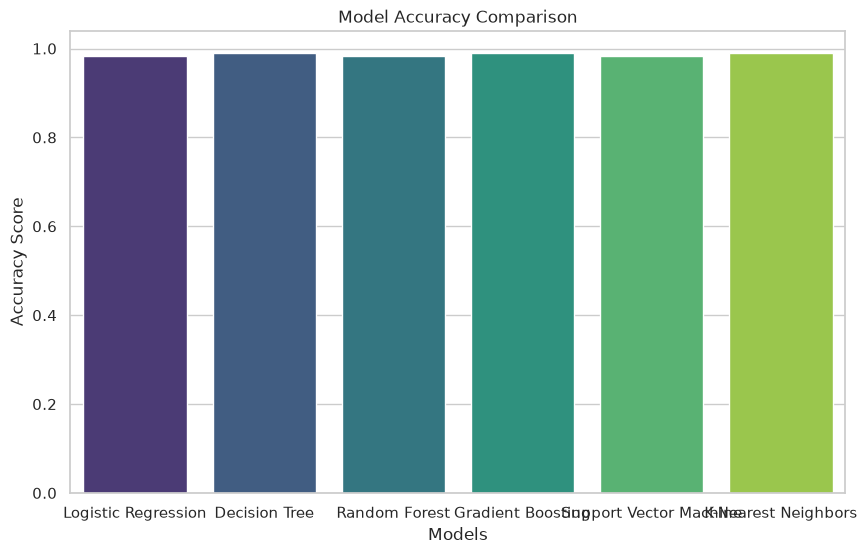

In [61]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine', 'K-Nearest Neighbors']
accuracy_scores = [.984,.99,.984,.99,.983,.99]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracy_scores, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.xlabel('Models')
plt.show()

In [62]:
x_train

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,state_code,Hour,Day_of_Week,Month
4227,4,0,1,1,110,110,44,6,1,1,3
4676,3,1,0,0,145,145,61,5,20,2,2
800,2,5,1,2,0,0,45,6,8,6,8
3671,2,5,1,2,0,0,96,6,10,3,9
4193,3,1,1,0,140,140,74,2,5,6,9
...,...,...,...,...,...,...,...,...,...,...,...
4426,1,0,0,2,70,70,67,8,0,6,6
466,6,1,0,1,140,140,61,6,3,0,4
3092,6,1,0,1,110,110,52,7,3,3,11
3772,4,0,0,1,120,100,67,0,8,3,4


In [66]:
x

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,state_code,Hour,Day_of_Week,Month
0,0,0,0,0,350,120,65,6,11,4,1
1,1,1,1,2,120,100,78,6,14,5,1
2,2,3,1,2,0,0,53,6,18,6,1
3,5,2,1,0,350,120,92,6,2,0,1
4,6,1,0,1,140,100,60,6,6,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,5,2,1,0,330,330,81,6,22,6,1
4996,6,1,0,1,125,125,64,6,13,1,1
4997,4,0,1,1,115,115,93,6,5,6,2
4998,3,1,0,0,145,145,57,6,20,0,2


In [67]:
y

0       0
1       0
2       1
3       0
4       0
       ..
4995    1
4996    1
4997    1
4998    1
4999    0
Name: Fraud_indicator, Length: 5000, dtype: int64

In [64]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(x,y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [65]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- Assuming you did something like this to train ---
# encode categorical features, split data into X and y, then:
# model = RandomForestClassifier()
# model.fit(X_train, y_train)

# 1. Save your trained model
joblib.dump(gb_model, "fastag_fraud_model.pkl")

# 2. Save any label encoders you used for categorical features
# (Example if you used a dictionary of label encoders)
# joblib.dump(label_encoders, 'label_encoders.pkl')

['fastag_fraud_model.pkl']